Крайниий ноутбук, финальный босс

Знаем уже что есть несбалансированность классов.

In [1]:
!pip install catboost

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

In [4]:
df = pd.read_pickle('dataset_after_eda.pkl')
df = df.drop_duplicates()
df.shape

(958, 211)

In [5]:
y = df['SI_above_8'].astype(int)
X = df.drop(['IC50, mM', 'CC50, mM', 'SI', 'IC50_above_median', 'CC50_above_median', 'SI_above_median', 'SI_above_8'], axis=1)

Напомним с EDA как распределились классы в датасете, не забудем если что использовать стратификацию чтобы в обе выборки попали классы

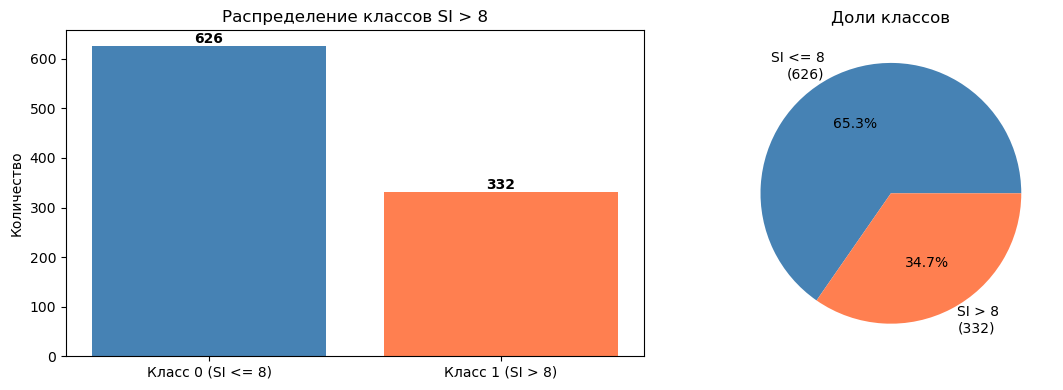

Дисбаланс: на каждый класс 1 приходится 1.9 объектов класса 0


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = y.value_counts()
axes[0].bar(['Класс 0 (SI <= 8)', 'Класс 1 (SI > 8)'],
            counts.values,
            color=['steelblue', 'coral'])
axes[0].set_title('Распределение классов SI > 8')
axes[0].set_ylabel('Количество')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values,
            labels=[f'SI <= 8\n({counts[0]})', f'SI > 8\n({counts[1]})'],
            autopct='%1.1f%%',
            colors=['steelblue', 'coral'])
axes[1].set_title('Доли классов')

plt.tight_layout()
plt.show()

print(f"Дисбаланс: на каждый класс 1 приходится {round(counts[0]/counts[1], 1)} объектов класса 0")

In [7]:
print(y.value_counts(normalize=True) * 100)

SI_above_8
0    65.344468
1    34.655532
Name: proportion, dtype: float64


Будем не только использовать стратификацию, но и использовать балансировку весов и stratifiedkfold кросс валидацию. Accuracy как метрику использовать не будем по понятным причинам.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

По классике для задачи выбраны ансамблевые методы Random Forest, Gradient Boosting и CatBoost, поскольку EDA показал слабые линейные корреляции признаков с таргетом поэтому линейные модели уже можно отсечь.

In [10]:
baseline_models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

baseline_results = []

for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    baseline_results.append({
        "Модель": name,
        "Этап": "До настройки",
        "F1": round(f1_score(y_test, y_pred), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4)
    })

In [11]:
df_si8 = pd.DataFrame(baseline_results).sort_values(by="ROC-AUC", ascending=False)
df_si8

,Модель,Этап,F1,ROC-AUC
1,Gradient Boosting,До настройки,0.4870,0.6983
0,Random Forest,До настройки,0.4912,0.6958
2,CatBoost,До настройки,0.4643,0.6941


Настроим гиперпараметры

In [12]:
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, None],
    'class_weight': ['balanced', 'balanced_subsample']
}

gb_param_grid = {
    'n_estimators': [150, 250],
    'learning_rate': [0.01, 0.03],
    'max_depth': [2, 3],
    'subsample': [0.7, 0.8],
    'max_features': ['sqrt']
}

cat_param_grid = {
    'iterations': [300, 500],
    'learning_rate': [0.03, 0.05],
    'depth': [4, 6],
    'auto_class_weights': ['Balanced']
}

cv_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                     rf_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=1)

cv_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                     gb_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=1)

cv_cat = GridSearchCV(CatBoostClassifier(random_state=42, verbose=0, allow_writing_files=False),
                      cat_param_grid, cv=cv_strategy, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Random Forest")
cv_rf.fit(X_train, y_train)

print("Gradient Boosting")
cv_gb.fit(X_train, y_train)

print("CatBoost")
cv_cat.fit(X_train, y_train)

best_models = {
    "Random Forest (Balanced)": cv_rf.best_estimator_,
    "Gradient Boosting (Reg)": cv_gb.best_estimator_,
    "CatBoost (Balanced)": cv_cat.best_estimator_
}

si8_results = []

for name, model in best_models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    si8_results.append({
        "Model": name,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

    print("Матрица ошибок для ",name)
    print(confusion_matrix(y_test, y_pred))

df_si8_final = pd.DataFrame(si8_results).sort_values(by="ROC-AUC", ascending=False)
df_si8_final

Random Forest
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Gradient Boosting
Fitting 3 folds for each of 16 candidates, totalling 48 fits
CatBoost
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Матрица ошибок для  Random Forest (Balanced)
[[103  22]
 [ 37  30]]
Матрица ошибок для  Gradient Boosting (Reg)
[[109  16]
 [ 42  25]]
Матрица ошибок для  CatBoost (Balanced)
[[93 32]
 [33 34]]


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest (Balanced),0.5769,0.4478,0.5042,0.7181
2,CatBoost (Balanced),0.5152,0.5075,0.5113,0.7127
1,Gradient Boosting (Reg),0.6098,0.3731,0.4630,0.6833


По ROC AUC
Random Forest вырос с 0.696 до 0.718
CatBoost вырос с 0.694 до 0.713
Gradient Boosting вырос с 0.698

Что можно в принципе сказать по матрицам. Все три модели склонны пропускать класс 1, сбалансированный CatBoost снова победил, находит больше реальных соединений с si>8, хотя в сравнении roc auc у rf лучше = 0.7181.

Попробуем подправить баланс классов, т.е. порог и посмотрим на метрики кэтбуста. Почему вообще выбор в пользу recall - с точки зрения бизнеса потерять лекарство катастрофически, но мы же смотрим не со стороны бизнеса а со стороны нахождения наиболее эффективных соединений.

Оптимальный порог: 0.32573894987309104
Максимальный F1 score при этом пороге: 0.6242774565999398


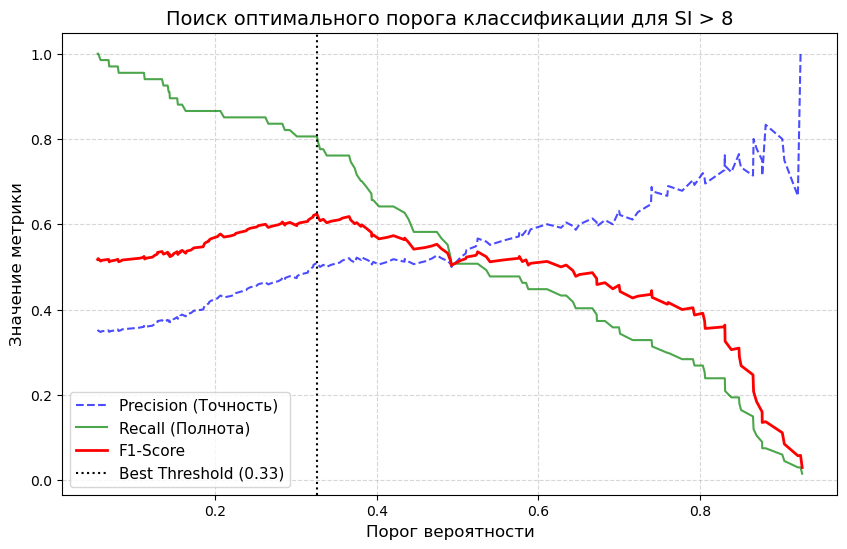

0.32573894987309104
[[73 52]
 [13 54]]
Precision: 0.5094339622641509
Recall: 0.8059701492537313
F1 score: 0.6242774566473989


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


y_scores = cv_cat.best_estimator_.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10) # eps чтобы не делить на 0
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print("Оптимальный порог:", best_threshold)
print("Максимальный F1 score при этом пороге:", best_f1)

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Точность)', alpha=0.7)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Полнота)', alpha=0.7)
plt.plot(thresholds, f1_scores[:-1], 'r-', linewidth=2, label='F1-Score')
plt.axvline(x=best_threshold, color='black', linestyle=':', label=f'Best Threshold ({best_threshold:.2f})')

plt.title('Поиск оптимального порога классификации для SI > 8', fontsize=14)
plt.xlabel('Порог вероятности', fontsize=12)
plt.ylabel('Значение метрики', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', fontsize=11)
plt.show()

y_pred_new_threshold = (y_scores >= best_threshold).astype(int)# нужно увидеть как меняется матрица

print(best_threshold)
print(confusion_matrix(y_test, y_pred_new_threshold))

print("Precision:",precision_score(y_test, y_pred_new_threshold))
print("Recall:",recall_score(y_test, y_pred_new_threshold))
print("F1 score:",f1_score(y_test, y_pred_new_threshold))

TP выросло до 54, FN вообще стало 13,  то есть модель стала мягче при пороге классов 0.3257

#ВЫВОД
Поскольку исходный датасет обладал дисбалансом классов, стандартный порог принятия решений приводил к искусственному занижению полноты модели. В результате анализа кривой PrecisionRecall был найден оптимальный порог вероятности 0.326, максимизирующий метрику F1. По итогу получили что смещение порога позволило повысить способность у модели идентифицировать соединения: полнота выросла до 80.6, а целевой баланс модели F1 увеличился до 0.6243. Модель CatBoost настроена, оптимизирована.